## End-to-End Machine Learning Assignment

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Loading Dataset Using Pandas

In [2]:
df = pd.read_csv("diamonds.csv")

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Basic Checks

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
df.shape

(53940, 11)

In [6]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
### Selecting numerical columns

In [10]:
numcols = df.select_dtypes(include = 'number').columns

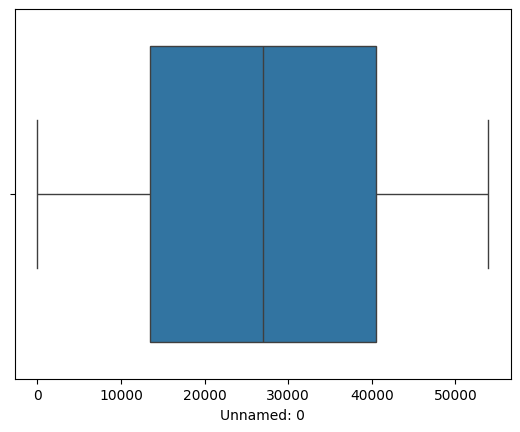

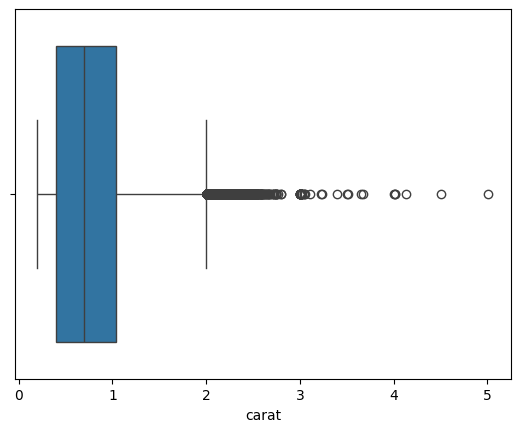

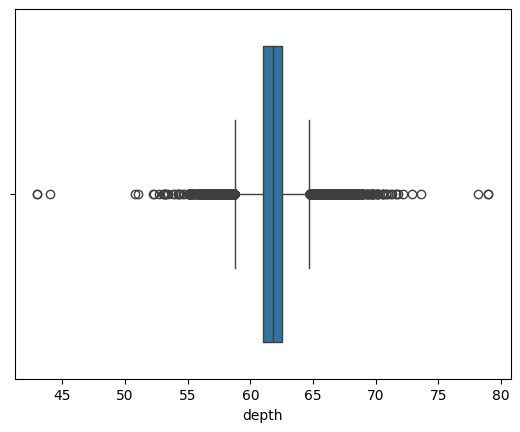

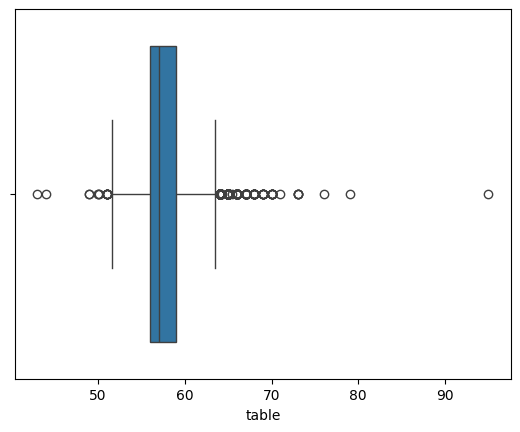

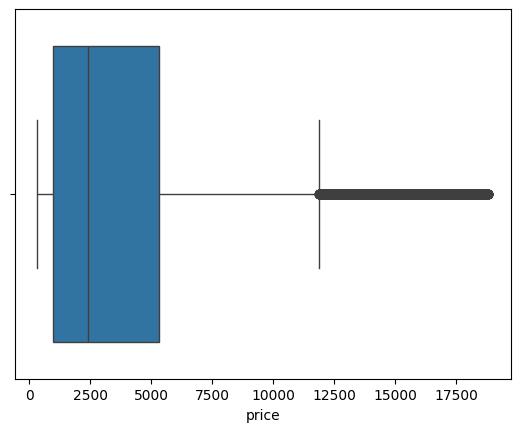

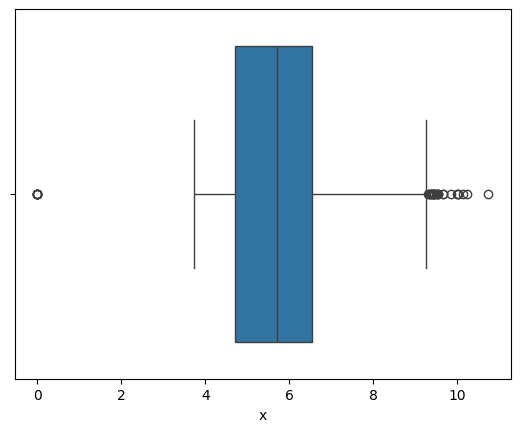

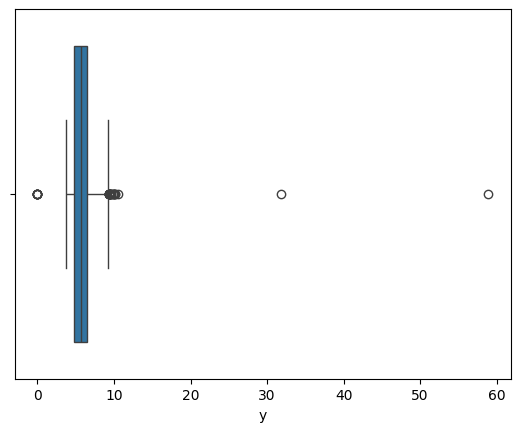

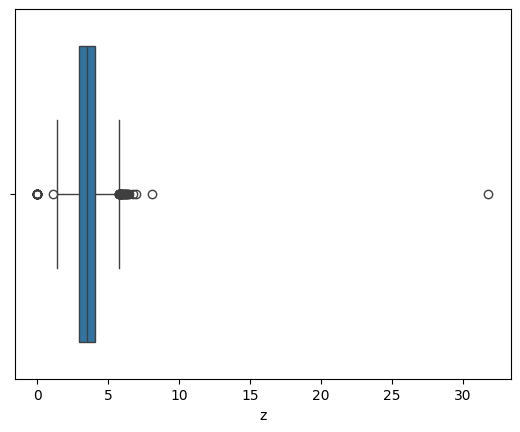

In [11]:
for col in numcols:
    sns.boxplot(x = df[col])
    plt.show()

#### Detect and Handling Outliers

In [12]:
for col in numcols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

numcols = df.select_dtypes(include = 'number').columns

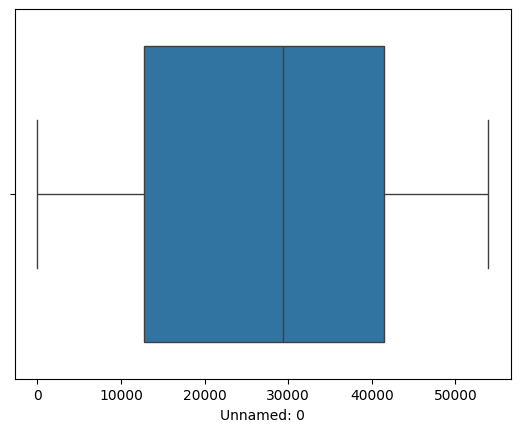

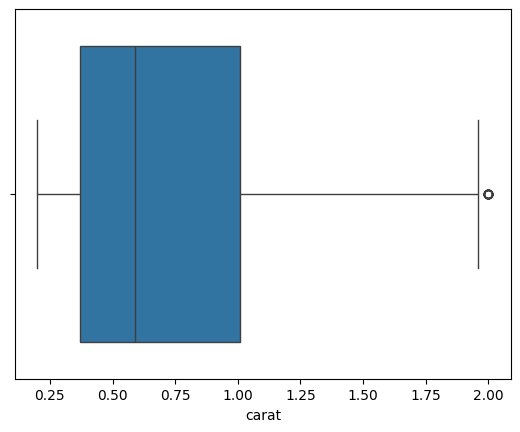

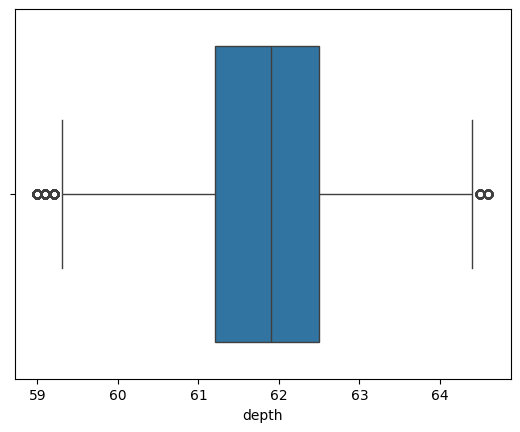

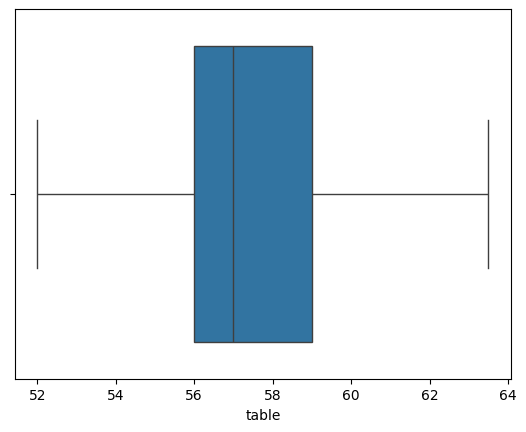

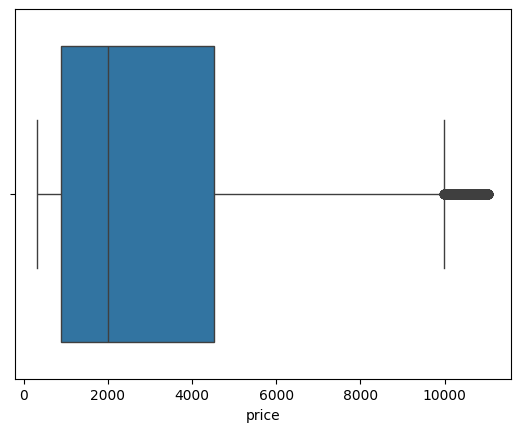

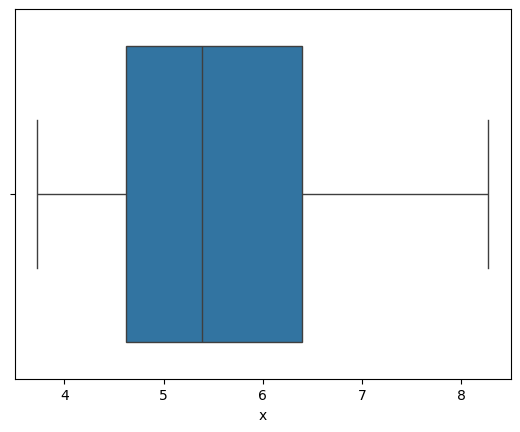

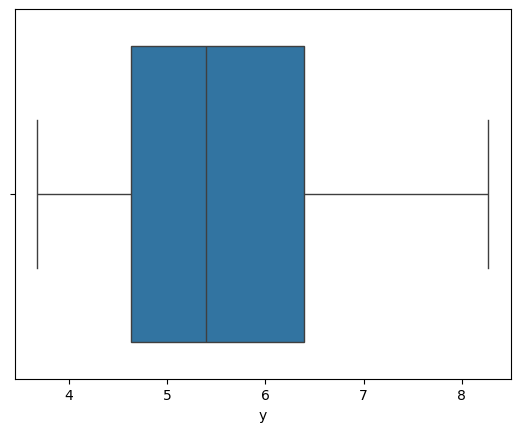

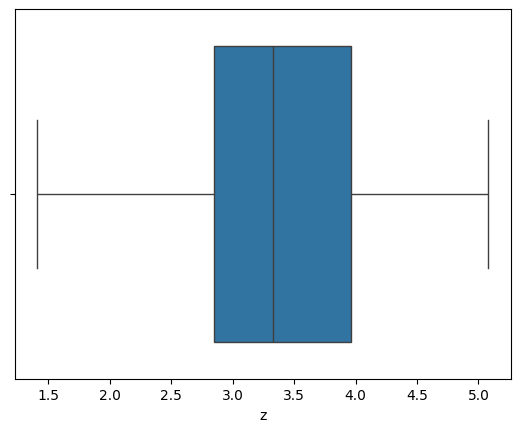

In [13]:
for col in numcols:
    sns.boxplot(x = df[col])
    plt.show()

### Feature Engineering

In [14]:
X = df.drop("price",axis = 1)
y = df['price']

In [15]:
##Feature selection
X = X.drop("Unnamed: 0",axis = 1)

In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Convert problematic string dtype columns
for col in df.select_dtypes(include=['string']).columns:
    df[col] = df[col].astype('object')


### Splitting For Train-Test 

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [18]:
#Identify column types:
numcols = X.select_dtypes(include = 'number').columns
catcols = X.select_dtypes(include = 'object').columns
print("Numerical:", numcols)
print("Categorical:", catcols)

Numerical: Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object')
Categorical: Index(['cut', 'color', 'clarity'], dtype='object')


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

ct = ColumnTransformer([
    ('num', StandardScaler(), numcols),
    ('cat', OneHotEncoder(handle_unknown="ignore"), catcols)])

In [20]:
# Fit only on training data
X_train_transformed = ct.fit_transform(X_train)

X_train_transformed = pd.DataFrame(X_train_transformed, columns=ct.get_feature_names_out())
# Transform test data
X_test_transformed = ct.transform(X_test)

#print("Shape:", X_transformed.shape)
#X_transformed.head()

### Model Building

In [21]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(X_train_transformed,y_train)

KNeighborsRegressor()

In [22]:
### 

In [23]:
y_pred = knn.predict(X_test_transformed)

C:\Users\DEEPTHI\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 291.41366801341013
RMSE: 500.5264968954058
R2 Score: 0.9632333820184904


In [25]:
print("Train score:", knn.score(X_train_transformed, y_train))
print("Test score:", knn.score(X_test_transformed, y_test))

Train score: 0.9764840713589974


C:\Users\DEEPTHI\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


Test score: 0.9632333820184904


In [26]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(knn, file)

print("model.pkl saved successfully")

model.pkl saved successfully


In [27]:
from IPython.display import FileLink

FileLink("model.pkl")

C:\Users\DEEPTHI\Desktop\innomatics_461\ML\swathi_mam\model.pkl

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

pipeline = Pipeline([
    ('preprocessor', ct),
    ('model', KNeighborsRegressor())
])

pipeline.fit(X_train, y_train)

import pickle
pickle.dump(pipeline, open("diamond_model.pkl", "wb"))

In [29]:
import sklearn
print(sklearn.__version__)

1.3.2
